# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [37]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [38]:
# Your code here
#a)
penguins.shape


(344, 8)

In [39]:
#b)
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [40]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [41]:
print(penguins['species'].value_counts())
print(penguins['sex'].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
sex
male      168
female    165
Name: count, dtype: int64


### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [42]:
# Your code here
#a)
cols_to_check = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
penguins_clean = penguins.dropna(subset=cols_to_check).copy()

In [43]:
#b)
print(f"The new shape of the data is: {penguins_clean.shape}")

The new shape of the data is: (333, 8)


### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [44]:
# Your code here
#a)
numeric_summary = penguins_clean.describe()
display(numeric_summary)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057,2008.042
std,5.469,1.969,14.016,805.216,0.813
min,32.100,13.100,172.000,2700.000,2007.000
25%,39.500,15.600,190.000,3550.000,2007.000
50%,44.500,17.300,197.000,4050.000,2008.000
75%,48.600,18.700,213.000,4775.000,2009.000
max,59.600,21.500,231.000,6300.000,2009.000


In [45]:
#b)
# 1. Select only the columns you want to analyze + the grouping column
numeric_cols = penguins_clean.select_dtypes('number').columns.tolist()
# Add 'species' back in so we can group by it
cols_to_use = ['species'] + numeric_cols

# 2. Group and aggregate
species_stats = penguins_clean[cols_to_use].groupby('species').agg(['mean', 'std'])

display(species_stats)

bill_length_mm        bill_depth_mm        flipper_length_mm         \
                    mean    std          mean    std              mean    std   
species                                                                         
Adelie            38.824  2.663        18.347  1.219           190.103  6.522   
Chinstrap         48.834  3.339        18.421  1.135           195.824  7.132   
Gentoo            47.568  3.106        14.997  0.986           217.235  6.585   

          body_mass_g               year         
                 mean      std      mean    std  
species                                          
Adelie       3706.164  458.620  2008.055  0.812  
Chinstrap    3733.088  384.335  2007.971  0.863  
Gentoo       5092.437  501.476  2008.067  0.789

### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [46]:
# Your code here
#a)
grouped_summary = penguins_clean.groupby(['species', 'sex'])[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].agg(['mean', 'count'])
display(grouped_summary)


bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938.971    34  
Gentoo    female    58    4679.741    58  
          male      61    5484.836    61

In [47]:
# Group by species and sex, calculate the mean of body_mass_g
avg_masses = penguins_clean.groupby(['species', 'sex'])[['body_mass_g']].mean()

# Sort by mass descending and take the very top row
largest_mass_row = avg_masses.sort_values('body_mass_g', ascending=False).head(1)

display(largest_mass_row)

,,body_mass_g
species,sex,
Gentoo,male,5484.836


### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [48]:

# Your code here
#a)
overall_corr = penguins_clean.select_dtypes('number').corr()
display(overall_corr)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000,-0.229,0.653,0.589,0.033
bill_depth_mm,-0.229,1.000,-0.578,-0.472,-0.048
flipper_length_mm,0.653,-0.578,1.000,0.873,0.151
body_mass_g,0.589,-0.472,0.873,1.000,0.022
year,0.033,-0.048,0.151,0.022,1.000


In [49]:
#b)
# 1. First, create a list of numeric columns + the grouping column
numeric_cols = penguins_clean.select_dtypes('number').columns.tolist()
cols_to_use = ['species'] + numeric_cols

# 2. Filter the dataframe, then group and correlate
species_corr = penguins_clean[cols_to_use].groupby('species').corr()

display(species_corr)

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
          year                        0.011         -0.235              0.328   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
          year                        0.042         -0.059              0.346   
Gentoo    bill_length_mm              1.000          0.654              0.664   
          bill_depth_mm               0.654          1.000              0.711   
          flipper_length_mm           0.664          0.711              1.000   
          body_mass_g                 0.667          0.723              0.711   
          year                        0.205          0.243              0.201   

                             body_mass_g   year  
species                                          
Adelie    bill_length_mm           0.544  0.011  
          bill_depth_mm            0.580 -0.235  
          flipper_length_mm        0.465  0.328  
          body_mass_g              1.000 -0.046  
          year                    -0.046  1.000  
Chinstrap bill_length_mm           0.514  0.042  
          bill_depth_mm            0.604 -0.059  
          flipper_length_mm        0.642  0.346  
          body_mass_g              1.000  0.037  
          year                     0.037  1.000  
Gentoo    bill_length_mm           0.667  0.205  
          bill_depth_mm            0.723  0.243  
          flipper_length_mm        0.711  0.201  
          body_mass_g              1.000  0.052  
          year                     0.052  1.000

In [50]:
#c)
print("Overall correlation (Bill Length vs Depth):")
print(penguins_clean['bill_length_mm'].corr(penguins_clean['bill_depth_mm']))

print("\nCorrelation by Species:")
print(penguins_clean.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr().iloc[0::2, 1])

Overall correlation (Bill Length vs Depth):
-0.2286256359130291

Correlation by Species:
species                  
Adelie     bill_length_mm    0.386
Chinstrap  bill_length_mm    0.654
Gentoo     bill_length_mm    0.654
Name: bill_depth_mm, dtype: float64


## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


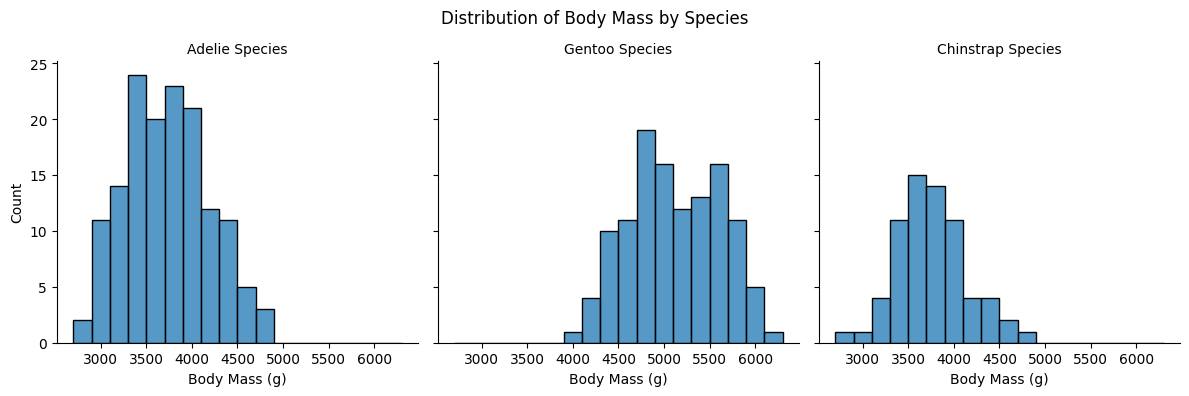

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create faceted histograms
g = sns.displot(data=penguins_clean, x="body_mass_g", col="species", 
                binwidth=200, height=4, aspect=1)

# Add titles and labels
g.set_axis_labels("Body Mass (g)", "Count")
g.set_titles("{col_name} Species")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Distribution of Body Mass by Species')

plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

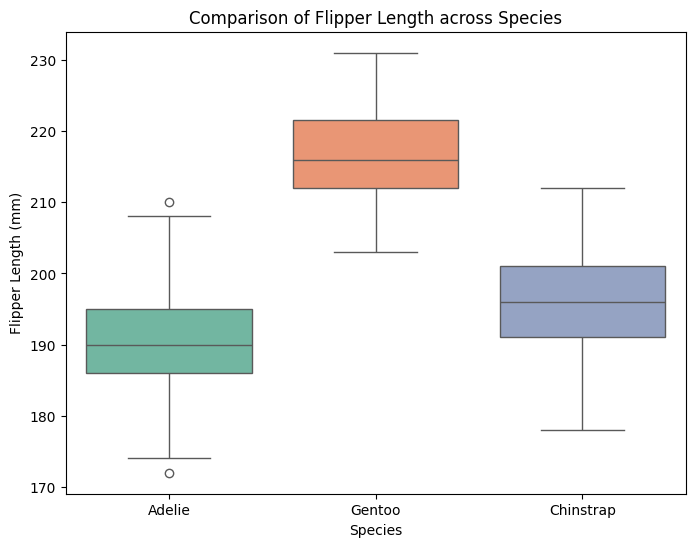

In [52]:
plt.figure(figsize=(8, 6))

# Create the boxplot
sns.boxplot(data=penguins_clean, x="species", y="flipper_length_mm", hue="species", palette="Set2")

# Customizing labels and title
plt.title("Comparison of Flipper Length across Species")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")

plt.show()

Based on the boxplots, Gentoo penguins have significantly higher median flipper lengths than both Adelie and Chinstrap species, with almost no overlap between their distributions. While the Adelie and Chinstrap penguins have very similar medians (around 190mm–195mm), Chinstraps tend to show a slightly larger overall spread and higher maximum values. This visualization clearly identifies the Gentoo species as the largest in terms of limb length within this dataset. 

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

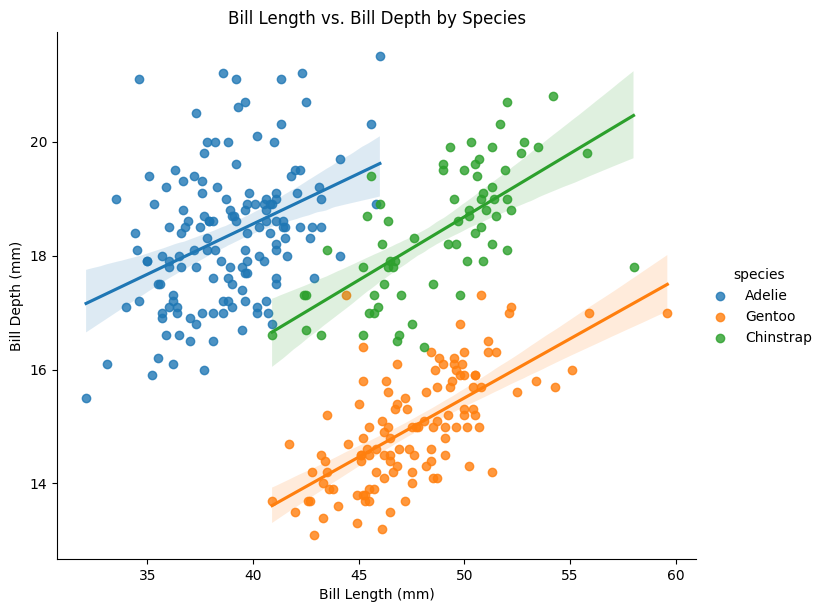

In [53]:
sns.lmplot(data=penguins_clean, x="bill_length_mm", y="bill_depth_mm", 
           hue="species", height=6, aspect=1.2)

plt.title("Bill Length vs. Bill Depth by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")

plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

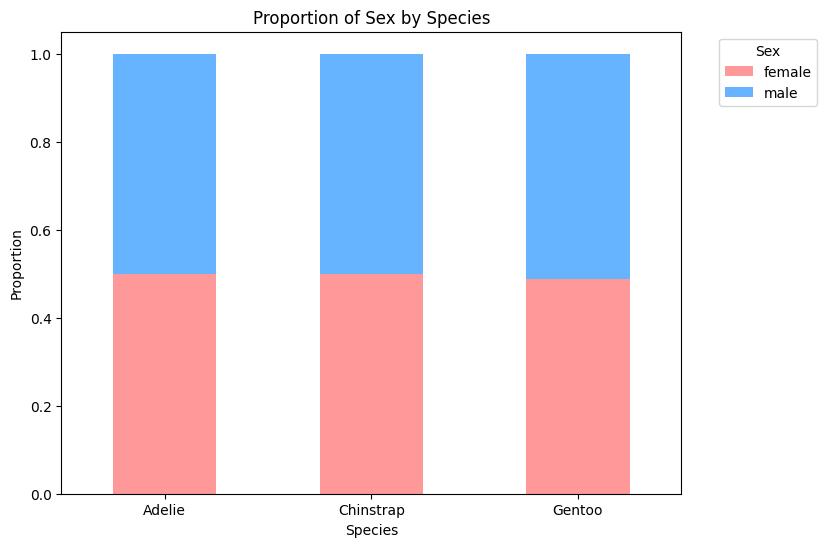

In [54]:
counts = pd.crosstab(penguins_clean['species'], penguins_clean['sex'], normalize='index')

# 2. Make the stacked bar chart
counts.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#ff9999','#66b3ff'])

# Customizing the plot
plt.title("Proportion of Sex by Species")
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0) # Keeps species names horizontal

plt.show()